# Лабораторная работа  
## Анализ и визуализация данных об успеваемости студентов

**Студент Сырчин АНдрей Дмитриевич (501965):**  
**Группа: Р3122**  
**Дата: 09.05.2026**

---

### Что нужно сделать
Заполните этот notebook по шагам:
1. загрузите датасет;
2. выполните первичный анализ;
3. обработайте данные;
4. создайте новые признаки;
5. выполните группировку и агрегацию;
6. постройте графики;
7. сделайте выводы.

> В большинстве ячеек код нужно написать самостоятельно.

## 1. Импорт библиотек

Импортируйте библиотеки, которые понадобятся в работе.

Минимально ожидается использование:
- `pandas`
- `matplotlib.pyplot`

При необходимости можно добавить и другие библиотеки.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Загрузка данных

Считайте CSV-файл в `DataFrame`.

Ожидается, что датасет лежит по относительному пути:
`data/StudentsPerformance.csv`

После загрузки данных выведите:
- первые 5 строк;
- размер таблицы.

In [2]:
# Загрузите датасет и выведите первые строки и размер таблицы
df = pd.read_csv('data/data_StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.size

8000

## 3. Первичный просмотр структуры данных

На этом этапе нужно посмотреть:
- названия столбцов;
- типы данных;
- базовую информацию о таблице.

Подумайте:
- какие признаки числовые;
- какие признаки категориальные.

In [4]:
# названия столбцов
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [5]:
# типы данных
df.dtypes

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

In [6]:
# Выведите названия столбцов, типы данных и базовую информацию о таблице

# базовая информация о таблице 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


## 4. Проверка пропущенных значений

Проверьте, есть ли в таблице пустые значения.

Кратко прокомментируйте результат:
- есть ли пропуски;
- в каких столбцах они находятся;
- требуется ли обработка.

In [7]:
# проверим кол-во пропусков в изначальном датасете
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

### Краткий комментарий
Напишите 1–3 предложения о результате проверки пропусков.

Проверив все значения в изначальном датасете, можно сказать, что во всех столбцах нет пропусков!

## 5. Переименование столбцов

Приведите названия столбцов к более удобному виду.

Рекомендуется:
- убрать пробелы;
- заменить специальные символы;
- использовать короткие и понятные имена.

Пример подхода:
- `math score` → `math_score`
- `test preparation course` → `test_prep`

После переименования снова выведите список столбцов.

In [8]:
# Переименуйте столбцы и выведите обновленный список
# Присваиваем новые имена столбцам
df.columns = ['gender', 'ethnicity', 'parent_edu', 'lunch', 'test_prep', 
              'math_score', 'reading_score', 'writing_score']

# Выводим обновленный список столбцов
print(df.columns)

Index(['gender', 'ethnicity', 'parent_edu', 'lunch', 'test_prep', 'math_score',
       'reading_score', 'writing_score'],
      dtype='str')


## 6. Создание новых признаков

На этом этапе нужно самостоятельно создать **не менее одного нового признака** на основе существующих столбцов.

Обязательный вариант:
- `average_score` — средний балл по трем предметам.

Можно добавить и другие признаки, если считаете это полезным.

In [9]:
# Создайте новый признак (минимум один)
df['average_score'] = round((df['math_score'] + df['writing_score'] + df['reading_score']) / 3, 2)
print(df['average_score'])

0      72.67
1      82.33
2      92.67
3      49.33
4      76.33
       ...  
995    94.00
996    57.33
997    65.00
998    74.33
999    83.00
Name: average_score, Length: 1000, dtype: float64


## 7. Описательная статистика

Постройте базовую статистику по числовым признакам.

Подумайте:
- какие значения являются типичными;
- есть ли большой разброс;
- какие признаки удобно анализировать дальше.

In [10]:
# Описательная статистика
stats = df.describe()
print(stats)

       math_score  reading_score  writing_score  average_score
count  1000.00000    1000.000000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000      67.770580
std      15.16308      14.600192      15.195657      14.257311
min       0.00000      17.000000      10.000000       9.000000
25%      57.00000      59.000000      57.750000      58.330000
50%      66.00000      70.000000      69.000000      68.330000
75%      77.00000      79.000000      79.000000      77.670000
max     100.00000     100.000000     100.000000     100.000000


In [11]:
# 

for col in stats.columns:
    mean_val = stats[col]['mean']
    median_val = stats[col]['50%']
    std_val = stats[col]['std']
    min_val = stats[col]['min']
    max_val = stats[col]['max']
    
    print(f"\nСтолбец: {col}")
    print(f"  Типичные значения: среднее={mean_val:.2f}, медиана={median_val:.2f}")
    print(f"  Разброс: std={std_val:.2f}, мин={min_val}, макс={max_val}")


Столбец: math_score
  Типичные значения: среднее=66.09, медиана=66.00
  Разброс: std=15.16, мин=0.0, макс=100.0

Столбец: reading_score
  Типичные значения: среднее=69.17, медиана=70.00
  Разброс: std=14.60, мин=17.0, макс=100.0

Столбец: writing_score
  Типичные значения: среднее=68.05, медиана=69.00
  Разброс: std=15.20, мин=10.0, макс=100.0

Столбец: average_score
  Типичные значения: среднее=67.77, медиана=68.33
  Разброс: std=14.26, мин=9.0, макс=100.0


In [12]:
# выбросы 
for col in stats.columns:    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Выбросы в {col}: {len(outliers)}")

Выбросы в math_score: 8
Выбросы в reading_score: 6
Выбросы в writing_score: 5
Выбросы в average_score: 6


### Краткий комментарий
Напишите 2–4 предложения по результатам описательной статистики.

#### *Cредние баллы по всем предметам близки друг к другу (66–69), медианы почти совпадают со средними - распределения примерно симметричны. Разброс умеренный (std примерно 14–15), но есть выбросы, особенно в математике.*

## 8. Выделение числовых и категориальных признаков

Сформируйте отдельно:
- список числовых признаков;
- список категориальных признаков.

In [13]:
# Получите списки числовых и категориальных признаков
numeric_features = df.select_dtypes(include=['number']).columns.tolist()
categorical_features = df.select_dtypes(exclude=['number']).columns.tolist()

print("Числовые признаки:", numeric_features)
print("Категориальные признаки:", categorical_features)

Числовые признаки: ['math_score', 'reading_score', 'writing_score', 'average_score']
Категориальные признаки: ['gender', 'ethnicity', 'parent_edu', 'lunch', 'test_prep']


## 9. Группировка и агрегация

Выполните группировку данных и вычислите агрегированные показатели.

Минимально нужно посчитать:
- средний балл по `test_prep`;
- средний балл по `gender`;
- средний балл по `parent_education`.

При необходимости можно добавить дополнительные группировки.

In [14]:
# Группировка по test_prep
avg_by_test_prep = df.groupby('test_prep')['average_score'].mean().reset_index()
print("Средний балл по подготовке к тесту:")
print(avg_by_test_prep)

# Группировка по gender
avg_by_gender = df.groupby('gender')['average_score'].mean().reset_index()
print("\nСредний балл по полу:")
print(avg_by_gender)

# Группировка по parent_edu
avg_by_parent_edu = df.groupby('parent_edu')['average_score'].mean().reset_index()
print("\nСредний балл по образованию родителей:")
print(avg_by_parent_edu)

Средний балл по подготовке к тесту:
   test_prep  average_score
0  completed      72.669469
1       none      65.038801

Средний балл по полу:
   gender  average_score
0  female      69.569498
1    male      65.837303

Средний балл по образованию родителей:
           parent_edu  average_score
0  associate's degree      69.568964
1   bachelor's degree      71.923983
2         high school      63.097194
3     master's degree      73.598644
4        some college      68.476106
5    some high school      65.107654


### Краткий комментарий
Опишите, какие различия между группами удалось заметить.

**По итогам группировки удалось выявить, что:**

1) Студенты, прошедшие подготовку к тесту, имеют значительно более высокий средний балл
2) Девочки показывают в среднем лучшие результаты, чем мальчики
3) Чем выше уровень образования родителей, тем выше средний балл ребёнка

## 10. Визуализация 1 — гистограмма

Постройте гистограмму для одного из числовых признаков.

Обязательный вариант:
- `math_score`

Не забудьте:
- заголовок;
- подпись оси X;
- подпись оси Y;
- сетку при необходимости.

Text(0, 0.5, 'Количество студентов')

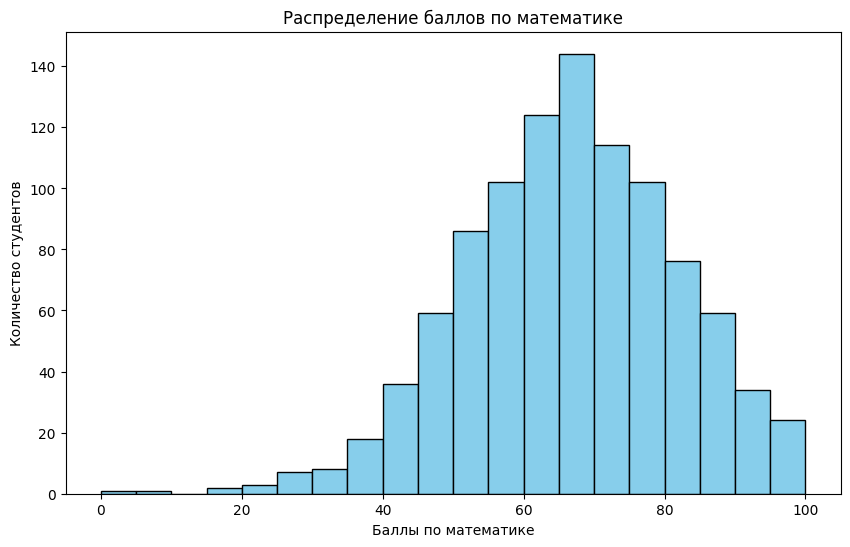

In [15]:
# math_score
plt.figure(figsize=(10, 6))
plt.hist(df['math_score'], bins=20, color='skyblue', edgecolor='black')
plt.title('Распределение баллов по математике')
plt.xlabel('Баллы по математике')
plt.ylabel('Количество студентов')

Text(0, 0.5, 'Количество студентов')

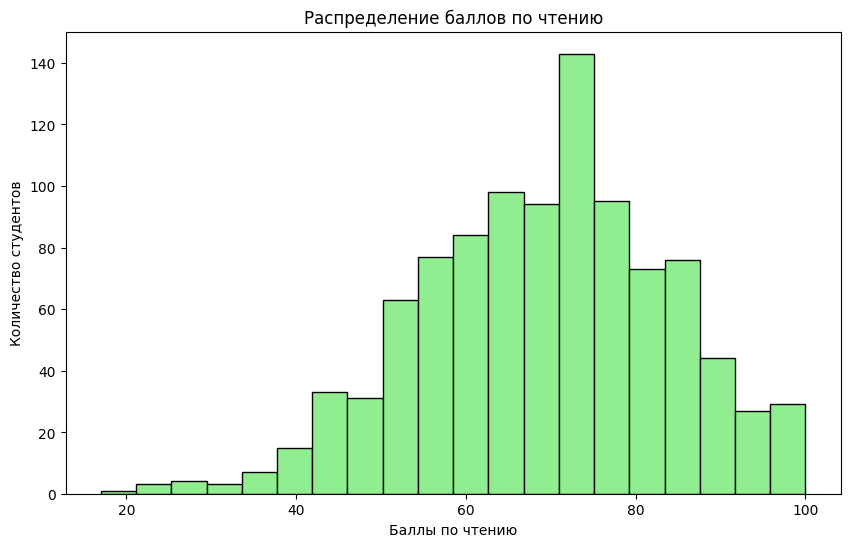

In [16]:
# reading_score
plt.figure(figsize=(10, 6))
plt.hist(df['reading_score'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Распределение баллов по чтению')
plt.xlabel('Баллы по чтению')
plt.ylabel('Количество студентов')

Text(0.5, 0, 'Баллы по письму')

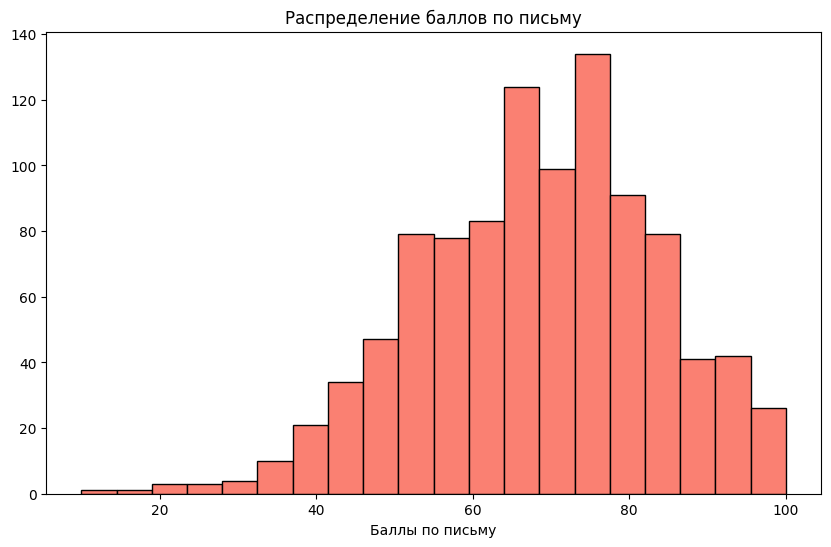

In [17]:
# wrining_score
plt.figure(figsize=(10, 6))
plt.hist(df['writing_score'], bins=20, color='salmon', edgecolor='black')
plt.title('Распределение баллов по письму')
plt.xlabel('Баллы по письму')

### Вывод по графику
Напишите 1–3 предложения.

**Исходя из гистограмм, можно сделать следующие выводы:**

1. Баллы по математике (math_score) имеют примерно нормальное распределение, средним значением около 65-70. 
Большинство студентов набрали от 50 до 80 баллов, с небольшим количеством выбросов в виде высоких и низких баллов.
2. Баллы по чтению (reading_score) также имеют примерно нормальное распределение, но с более высоким средним значением около 70-75. 
Большинство студентов набрали от 60 до 90 баллов, с меньшим количеством выбросов по сравнению с математикой.
3. Баллы по письму (writing_score) имеют более широкое распределение, с средним значением около 65-70.
Большинство студентов набрали от 50 до 80 баллов, но есть больше выбросов в виде высоких и низких баллов по сравнению с чтением.

## 11. Визуализация 2 — столбчатая диаграмма

Постройте столбчатую диаграмму среднего балла по `test_prep`.

Text(0.5, 1.0, 'Средний балл по подготовке к тесту')

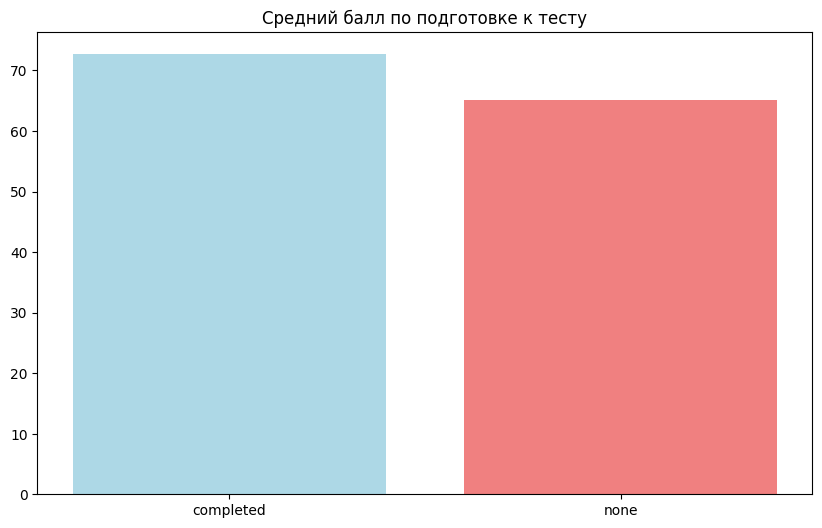

In [18]:
plt.figure(figsize=(10, 6))
plt.bar(avg_by_test_prep['test_prep'], avg_by_test_prep['average_score'], color=['lightblue', 'lightcoral'])
plt.title('Средний балл по подготовке к тесту')

Средний балл по подготовке к тесту выше у студентов, которые прошли подготовку, 
что может свидетельствовать о положительном влиянии подготовки на результаты тестов.

## 12. Визуализация 3 — столбчатая диаграмма

Постройте столбчатую диаграмму среднего балла по `gender`.

Text(0.5, 1.0, 'Средний балл по полу')

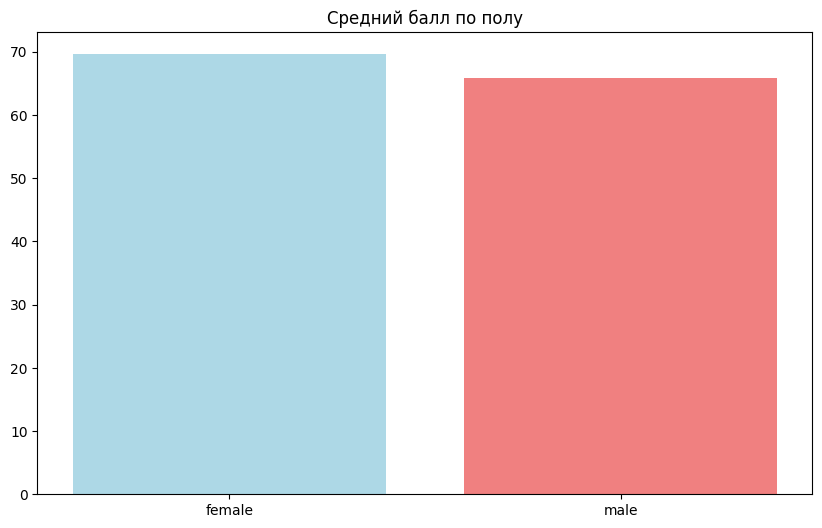

In [19]:
# Постройте столбчатую диаграмму по gender
plt.figure(figsize=(10, 6))
plt.bar(avg_by_gender['gender'], avg_by_gender['average_score'], color=['lightblue', 'lightcoral'])
plt.title('Средний балл по полу')

### Вывод по графику
Напишите 1–3 предложения.

**Исоходя из гарфика можно сделать вывод, что средний балл у девочек выше, чем у мальчиков.**

## 13. Визуализация 4 — диаграмма рассеяния

Постройте диаграмму рассеяния для зависимости между двумя числовыми признаками.

Обязательный вариант:
- `math_score` и `reading_score`

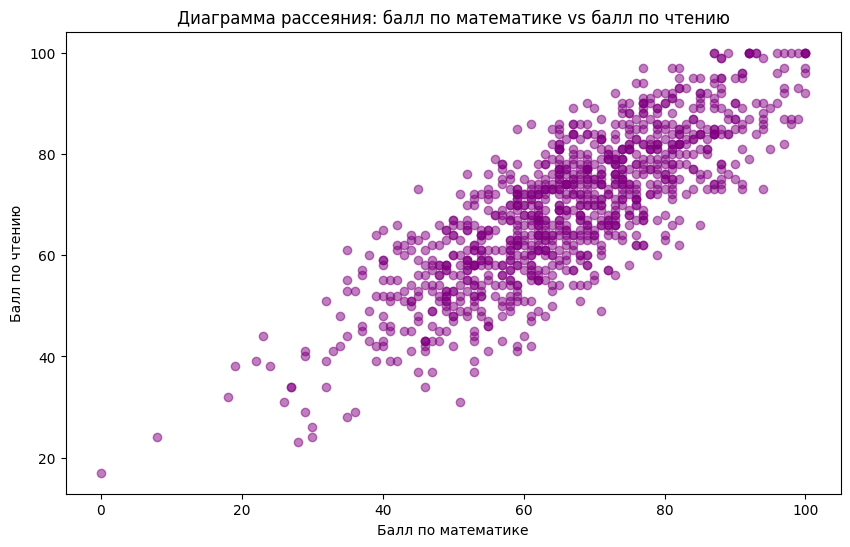

In [20]:
# Постройте диаграмму рассеяния
plt.figure(figsize=(10, 6))
plt.scatter(df['math_score'], df['reading_score'], alpha=0.5, color='purple')
plt.title('Диаграмма рассеяния: балл по математике vs балл по чтению')
plt.xlabel('Балл по математике')
plt.ylabel('Балл по чтению')
plt.show()

### Вывод по графику
Напишите 1–3 предложения.

Диаграмма рассеяния показывает устойчивую положительную корреляцию между баллами по математике и чтению: студенты, хорошо успевающие по одному предмету, склонны показывать хорошие результаты и по другому. Наиболее плотное скопление точек наблюдается в области средних и высоких баллов (60–90), что говорит о преобладании успевающих студентов. Наличие отдельных выбросов указывает на возможные индивидуальные особенности или трудности в определённых предметах.

## 14. Дополнительная визуализация

Добавьте **еще один график самостоятельно**.

Можно выбрать один из вариантов:
- график по `parent_education`;
- график по `lunch`;
- boxplot;
- еще одна гистограмма;
- другой осмысленный вариант.

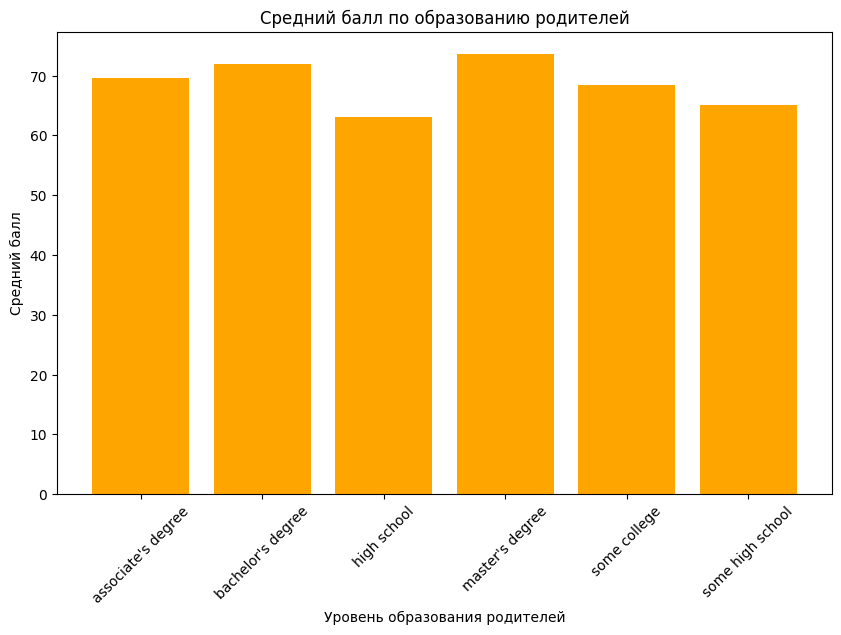

In [21]:
# Постройте дополнительный график
plt.figure(figsize=(10, 6))
plt.bar(avg_by_parent_edu['parent_edu'], avg_by_parent_edu['average_score'], color='orange')
plt.title('Средний балл по образованию родителей')
plt.xlabel('Уровень образования родителей')
plt.ylabel('Средний балл')
plt.xticks(rotation=45)
plt.show()

### Вывод по графику
Напишите 1–3 предложения.

График показывает, что средний балл растёт с повышением уровня образования родителей. Наивысшие результаты у студентов с родителями, имеющими степень магистра или бакалавра, а самые низкие - у тех, чьи родители имеют неполное среднее образование. Это подтверждает связь между уровнем образования родителей и успеваемостью.

## 15. Итоговый вывод

В финале кратко ответьте:
1. Что было сделано в работе?
2. Какие библиотеки и методы были использованы?
3. Какие закономерности удалось заметить?
4. Какие трудности возникли в процессе выполнения?

1. В работе данные были загружены из CSV, проведён первичный анализ структуры, проверка на пропуски, переименованы столбцы, создан новый признак `average_score`, рассчитана описательная статистика, выполнена группировка, построены графики.

2. Использовались библиотеки `pandas` и `matplotlib.pyplot`; методы `read_csv`, `head`, `info`, `isnull`, `groupby`, `describe`, `plot`/`hist`/`scatter`, а также переименования столбцов и создания нового признака.

3. Выявлены закономерности: подготовка к тесту связана с более высоким средним баллом, у девушек результаты выше, чем у мальчиков, и чем выше образование родителей, тем выше средний балл ребёнка; между `math_score` и `reading_score` наблюдается положительная корреляция.

4. Трудностей не возникло, данные оказались чистыми, без пропусков; основной практической задачей было правильно оформить анализ и визуализации.

## 16. Проверка перед сдачей

Перед отправкой убедитесь, что:
- все ячейки выполняются без ошибок;
- код написан последовательно и понятно;
- новые признаки действительно созданы вами;
- столбцы переименованы;
- построено не менее 4 обязательных графиков;
- под каждым графиком есть вывод;
- notebook сохранен после выполнения `Restart & Run All`.

# Выполнено в SourceCraft CI
- Время: 2026-05-04T17:20:56.787331+00:00
- Ноутбук успешно выполнен в облачной среде
- Все ячейки проверены на ошибки